In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/placementdata.csv")

In [4]:
df

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed


In [5]:
df.isnull().sum()

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [6]:
df = df.dropna()

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
df

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks,ExtracurricularActivities_Yes,PlacementTraining_Yes,PlacementStatus_Placed
0,1,7.5,1,1,1,65,4.4,61,79,False,False,False
1,2,8.9,0,3,2,90,4.0,78,82,True,True,True
2,3,7.3,1,2,2,82,4.8,79,80,True,False,False
3,4,7.5,1,1,2,85,4.4,81,80,True,True,True
4,5,8.3,1,2,2,86,4.5,74,88,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7.5,1,1,2,72,3.9,85,66,True,False,False
9996,9997,7.4,0,1,0,90,4.8,84,67,False,False,True
9997,9998,8.4,1,3,0,70,4.8,79,81,True,True,True
9998,9999,8.9,0,3,2,87,4.8,71,85,True,True,True


In [9]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression

In [14]:
lr_model=LogisticRegression()
lr_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [15]:
lr_pred = lr_model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [18]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Accuracy: 0.7725
[[931 241]
 [214 614]]
              precision    recall  f1-score   support

       False       0.81      0.79      0.80      1172
        True       0.72      0.74      0.73       828

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.77      0.77      0.77      2000



In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
dt = DecisionTreeClassifier(random_state=42)


In [21]:
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [22]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy: 0.719
[[888 284]
 [278 550]]
              precision    recall  f1-score   support

       False       0.76      0.76      0.76      1172
        True       0.66      0.66      0.66       828

    accuracy                           0.72      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.72      0.72      0.72      2000



In [23]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [25]:
knn_pred = knn.predict(X_test)

In [26]:
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

Accuracy: 0.7405
[[904 268]
 [251 577]]
              precision    recall  f1-score   support

       False       0.78      0.77      0.78      1172
        True       0.68      0.70      0.69       828

    accuracy                           0.74      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.74      0.74      0.74      2000



In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
rf_pred = rf.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.788
[[978 194]
 [230 598]]
              precision    recall  f1-score   support

       False       0.81      0.83      0.82      1172
        True       0.76      0.72      0.74       828

    accuracy                           0.79      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000



In [31]:
accuracy = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "KNN": accuracy_score(y_test, knn_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred)
}

In [41]:
for model in accuracy:
    print(model, ":", round(accuracy[model] * 100, 2), "%")
print('best model:',max(accuracy))

Logistic Regression : 77.25 %
KNN : 74.05 %
Decision Tree : 71.9 %
Random Forest : 78.8 %
best model: Random Forest


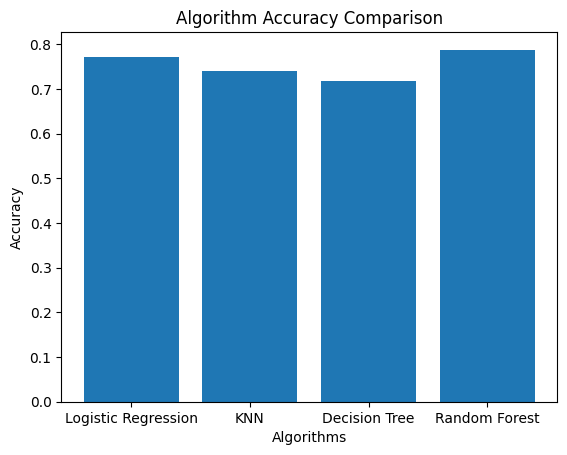

In [43]:
plt.bar(accuracy.keys(), accuracy.values())
plt.title("Algorithm Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.show()

In [46]:
import joblib

In [47]:
joblib.dump(rf, "model.pkl")

['model.pkl']